imports + device settings

In [ ]:
import os
from pathlib import Path

import torch
import random
import numpy as np
from torch.utils.data import DataLoader, random_split, Dataset, Subset
from torchvision import datasets, transforms, models
from PIL import Image
import matplotlib.pyplot as plt
import torch.nn as nn
import pandas as pd

torch.manual_seed(42)
random.seed(42)
np.random.seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Paths
data_dir = Path("kaggle-dataset")
train_dir = data_dir / "train"
test_dir = data_dir / "test"

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


dataset resize + augmentation

In [2]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

class TestDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_names = sorted([
            f for f in os.listdir(root_dir)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ])

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        img_name = self.image_names[idx]
        img_path = os.path.join(self.root_dir, img_name)
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, img_name

test_dataset = TestDataset(test_dir, transform=test_transform)

full_train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
full_val_dataset = datasets.ImageFolder(train_dir, transform=val_transform)

class_names = full_train_dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)
print("Total images:", len(full_train_dataset))
print("Total validation images:", len(full_val_dataset))

Classes: ['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '5', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '6', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '7', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '8', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '9', '90', '91', '92', '93', '94', '95', '96', '97', '98', '99']
Number of classes: 100
Total images: 1079
Total validation images: 1079


split train + val sets + load data + load transfer model (resnet50)

In [3]:
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_subset, val_subset = random_split(
    range(len(full_train_dataset)),
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_indices = train_subset.indices
val_indices = val_subset.indices

train_dataset = Subset(full_train_dataset, train_indices)
val_dataset = Subset(full_val_dataset, val_indices)

print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))

batch_size = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
)

val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT)

Train size: 863
Val size: 216


freeze layers + alter classifiers

In [4]:
for param in model.parameters():
    param.requires_grad = False

in_features = model.classifier[2].in_features

model.classifier[2] = nn.Linear(in_features, num_classes)

for param in model.classifier.parameters():
    param.requires_grad = True

for param in model.features[7].parameters():
    param.requires_grad = True

for param in model.features[5:].parameters():
    param.requires_grad = True


model = model.to(device)

training function

In [5]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW([
    {"params": model.features[5:].parameters(), "lr": 3e-5},
    {"params": model.classifier.parameters(), "lr": 3e-4},
], weight_decay=1e-5)

def train_one_epoch(model, loader):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        batch_size = x.size(0)
        total_loss += loss.item() * batch_size

        preds = logits.argmax(dim=1)
        total_correct += (preds == y).sum().item()
        total_samples += batch_size

    return total_loss / total_samples, total_correct / total_samples


validation

In [6]:
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    for x, y in loader:
        x = x.to(device)
        y = y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        batch_size = y.size(0)
        total_loss += loss.item() * batch_size
        preds = logits.argmax(dim=1)
        total_correct += (preds == y).sum().item()
        total_samples += batch_size
    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples
    return avg_loss, accuracy



training loop

In [7]:
epochs = 25
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0
best_epoch = -1
ckpt_path = "./checkpoints/best_convnext_tiny_baseline.pt"
os.makedirs(os.path.dirname(ckpt_path), exist_ok=True)


for epoch in range(1, epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc = evaluate(model, val_loader)
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "epoch": epoch,
            },
            ckpt_path,
        )
    print(
        f"Epoch [{epoch}/{epochs}] "
        f"train_loss={train_loss} train_acc={train_acc} "
        f"val_loss={val_loss} val_acc={val_acc}"
    )


print("Best val acc:", best_val_acc, "at epoch", best_epoch)
print("Saved to:", ckpt_path)

Epoch [1/25] train_loss=4.205120433385237 train_acc=0.11935110081112399 val_loss=3.6948749400951244 val_acc=0.2037037037037037
Epoch [2/25] train_loss=3.101847035307459 train_acc=0.43105446118192353 val_loss=2.9200609701651112 val_acc=0.39351851851851855
Epoch [3/25] train_loss=2.280761733392161 train_acc=0.6778679026651216 val_loss=2.479289867259838 val_acc=0.49537037037037035
Epoch [4/25] train_loss=1.740778502970416 train_acc=0.847045191193511 val_loss=2.219981043427079 val_acc=0.5601851851851852
Epoch [5/25] train_loss=1.392233802711425 train_acc=0.9466975666280417 val_loss=2.0615151281710022 val_acc=0.5972222222222222
Epoch [6/25] train_loss=1.1812570039808818 train_acc=0.9652375434530707 val_loss=1.9633393817477756 val_acc=0.6342592592592593
Epoch [7/25] train_loss=1.047749328447521 train_acc=0.9872537659327926 val_loss=1.9158884154425726 val_acc=0.6388888888888888
Epoch [8/25] train_loss=0.9819675225371696 train_acc=0.9930475086906141 val_loss=1.8809548881318834 val_acc=0.648148

plot

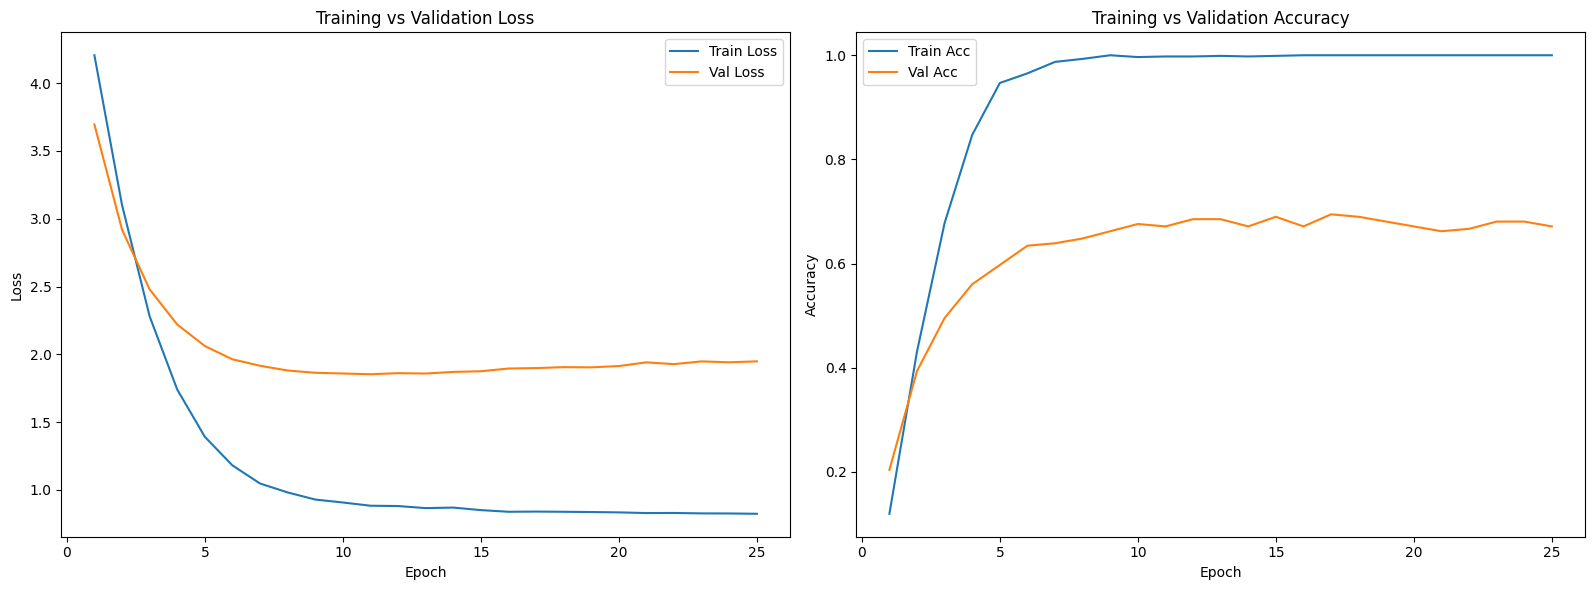

In [8]:
epochs_range = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(24, 6))
plt.subplot(1, 3, 1)
plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(epochs_range, history["train_acc"], label="Train Acc")
plt.plot(epochs_range, history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()


plt.tight_layout()
plt.show()

# ========== YOUR CODE ENDS HERE ============

test validation

In [9]:
ckpt = torch.load(ckpt_path, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])

idx_to_class = {v: k for k, v in full_train_dataset.class_to_idx.items()}

@torch.no_grad()
def predict(model, loader):
    model.eval()

    filenames = []
    predictions = []

    for x, names in loader:
        x = x.to(device)
        logits = model(x)
        pred_idxs = torch.argmax(logits, dim=1).cpu().tolist()

        pred_labels = [int(idx_to_class[i]) for i in pred_idxs]

        filenames.extend(names)
        predictions.extend(pred_labels)

    return filenames, predictions

filenames, predictions = predict(model, test_loader)

submission = pd.DataFrame({
    "ID": filenames,
    "Label": predictions,
})

submission.to_csv("submission.csv", index=False)
submission.head()

,ID,Label
0,0.jpg,62
1,1.jpg,43
2,10.jpg,75
3,100.jpg,48
4,1000.jpg,31
